# Bundle Clustering

## 1. Importing / Installing Packages

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import colors  # ✅ needed import

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import folium

from sklearn.cluster import DBSCAN
from scipy.spatial import ConvexHull

from bayes_opt import BayesianOptimization

from src.utils import CustomLogger # Importing CustomLogger class from custom

## 2. Initiliazing the Logger

In [2]:
# Create an instance of CustomLogger with logger name and log directory
logger_instance = CustomLogger("well_clustering","clustering",
                               r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\Python\Parent_Child_Spacing\logs")

# Get the logger
logger = logger_instance.get_logger()

## 3. Data Import

### 3.1 Reading Filtered Header and midpoints

In [3]:
# Reading WellHeader excel file to dataframe
df_raw_wellheader = pd.read_csv(
    r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\For Matt\Well Header\Header_Filtered.csv"
        ,usecols=["uwi", "well_name", "operator", "rsv_cat", "bench"] ,dtype={"uwi":str})

In [4]:
df_raw_wellheader

,uwi,well_name,operator,rsv_cat,bench
0,42003002890200,UNIVERSITY BLOCK 9 4AB,Exxon Mobil,02PDNP,MISSISSIPPIAN
1,42003029150100,UNIVERSITY BLOCK 9 6AO,Exxon Mobil,02PDNP,SUB-WOODFORD
2,42003029190100,UNIVERSITY BLOCK 9 7AO,Exxon Mobil,02PDNP,SUB-WOODFORD
3,42003029190200,UNIVERSITY BLOCK 9 7AO,Exxon Mobil,02PDNP,SUB-WOODFORD
4,42003029720300,UNIVERSITY BLOCK 9 3AT,Exxon Mobil,01PDP,SUB-WOODFORD
...,...,...,...,...,...
1991,42501376070000,RUSTY JOHNNY A 604-577 15XH,Riley Permian,03PUD,WOLFCAMP
1992,42501376080000,RUSTY JOHNNY B 604-577 2XH,Riley Permian,03PUD,WOLFCAMP
1993,42501376090000,JOSEY WALES A 640-669 8XH,Riley Permian,03PUD,WOLFCAMP
1994,42501376100000,RUSTY CRANE 604 25H,Riley Permian,03PUD,WOLFCAMP


### 3.2 Reading Mid-Points data frame

In [5]:
df_midpoints = pd.read_csv(r"C:\Users\Apoorva.Saxena\OneDrive - Sitio Royalties\Desktop\Project - Apoorva\For Matt\Directional Surveys\Lateral_Midpoints.csv",
                           dtype={"uwi":str})

In [6]:
df_midpoints

,uwi,heel_lat,heel_lon,toe_lat,toe_lon,mid_Lat,mid_Lon
0,30025410040100,33.128186,-103.063231,33.139705,-103.063334,33.133946,-103.063283
1,30025421210000,33.113373,-103.069194,33.125204,-103.069167,33.119289,-103.069181
2,30025426220000,33.113377,-103.072581,33.125239,-103.073067,33.119308,-103.072824
3,30025428730000,33.113636,-103.063432,33.125201,-103.063393,33.119418,-103.063413
4,30025435920100,33.097298,-103.074979,33.111496,-103.075177,33.104397,-103.075078
...,...,...,...,...,...,...,...
2010,42501376070000,33.095593,-102.908611,33.124152,-102.907813,33.109872,-102.908212
2011,42501376080000,33.095416,-102.910903,33.124376,-102.910116,33.109896,-102.910510
2012,42501376090000,33.074192,-102.904032,33.095278,-102.903988,33.084735,-102.904010
2013,42501376100000,33.095262,-102.913369,33.109847,-102.913430,33.102554,-102.913399


## 4. Data Preprocessing

### 4.1 Filtering midpoints to only include those present in the wellheader

In [7]:
df_midpoints_filter = df_midpoints[df_midpoints["uwi"].isin(df_raw_wellheader["uwi"].unique())].reset_index(drop=True).copy()

## 5. Feature Engineering

<Axes: xlabel='mid_Lat', ylabel='mid_Lon'>

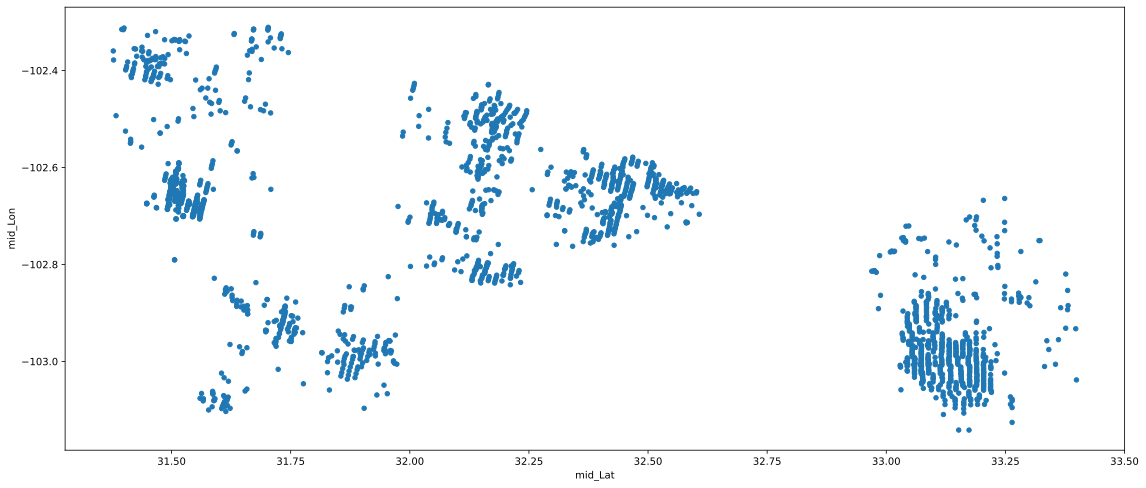

In [8]:
df_midpoints_filter.plot(kind='scatter',x='mid_Lat',y='mid_Lon',figsize=(19,8))

## 6. DBSCAN

### 6.1 Defining Functions

In [9]:
def haversine_distance(lon1, lat1, lon2, lat2,**kwargs):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    All args must be of equal length.

    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km


def dbscan_cluster(latitudes,longitudes,epsilon,min_samples,**kwargs):
    '''
    Function to perform DBSCAN clustering for given parameters.
    
    '''
    
    # convert epsilon from km to radians
    kms_per_radian = 6371.0088
    epsilon /= kms_per_radian
    
    # set up the algorithm
    dbscan = DBSCAN(
        eps = epsilon,
        min_samples = min_samples,
        algorithm = 'ball_tree',
        metric = 'haversine',
        **kwargs
    )
    
    # fit the algorithm
    dbscan.fit(
        np.radians(
            [x for x in zip(latitudes,longitudes)]
        )
    )
    
    # return the cluster labels
    return pd.Series(dbscan.labels_)


def vertex_centroid_distance(latitudes,longitudes,**kwargs):
    '''
    Function to calculate the average distance from the vertices of a convex hull
    (derived from latitude x longitude pairs) to the centroid of said convex hull.
    
    Centroid is taken to be the unweighted average of all co-ordinate pairs.
    
    '''
    
    # co-ordinates of centre
    # take a simple average
    centre_long = longitudes.mean()
    centre_lats = latitudes.mean()
    
    # collapse two points into line
    if len(latitudes) < 3:
        distances = haversine_distance(
            longitudes,
            latitudes,
            centre_long,
            centre_lats,
            **kwargs).mean()
    
    else:
        # convex hull
        convex_hull = ConvexHull([x for x in zip(latitudes,longitudes)],**kwargs)

        # now get co-ordinates of vertices
        vertex_longs = longitudes.iloc[convex_hull.vertices]
        vertex_lats = latitudes.iloc[convex_hull.vertices]

        # now get
        distances = haversine_distance(
            vertex_longs,
            vertex_lats,
            centre_long,
            centre_lats,
            **kwargs).mean()

    # return average distance
    return distances.mean() if not np.isnan(distances) else 0.0


def calculate_average_values_in_disctionary(dictionary:dict):
    return -1*(sum(dictionary.values())/len(dictionary)) if dictionary else None


def black_box_function(epsilon, min_samples):
    """
    Function with unknown internals we wish to maximize.

    This is just serving as an example, for all intents and
    purposes think of the internals of this function, i.e.: the process
    which generates its output values, as unknown.

    DataFrame: Dataframe with Lat & Long
    """
    df = df_midpoints_filter[['mid_Lat','mid_Lon']].copy()

    df.drop_duplicates(inplace=True)

    df['cluster'] = dbscan_cluster(latitudes=df['mid_Lat'],longitudes=df['mid_Lon'],
                                   epsilon=epsilon,min_samples=int(min_samples))
    
    vertex_dist = {}

    for cluster in df['cluster'].unique():

        df_cluster_lat_longs = df[df['cluster']==cluster].loc[:,['mid_Lat','mid_Lon']].copy()

        vertex_dist[cluster] = vertex_centroid_distance(latitudes=df_cluster_lat_longs['mid_Lat'], longitudes=df_cluster_lat_longs['mid_Lon'])

    return calculate_average_values_in_disctionary(vertex_dist)


def plot_clusters(df: pd.DataFrame, eps: float, min_samp: int):
    df_result = df.copy()

    df_result['cluster'] = dbscan_cluster(
        latitudes=df_result['mid_Lat'],
        longitudes=df_result['mid_Lon'],
        epsilon=eps,
        min_samples=min_samp
    )

    m = folium.Map(
        location=[df_result['mid_Lat'].mean(), df_result['mid_Lon'].mean()],
        tiles="OpenStreetMap",
        zoom_start=11
    )

    # Create a colormap for the unique cluster labels
    cmap = plt.get_cmap('hsv', len(df_result['cluster'].unique()))

    # Create a color dictionary for each unique cluster
    color_map = {cluster: colors.rgb2hex(cmap(i)) 
                 for i, cluster in enumerate(df_result['cluster'].unique())}

    # Add a circle marker for each point
    for _, row in df_result.iterrows():
        folium.CircleMarker(
            location=[row['mid_Lat'], row['mid_Lon']],
            radius=5,
            color="white",
            fill=True,
            popup=f"{row['well_name']}, Cluster: {row['cluster']}",
            fill_color=color_map[row['cluster']],
            fill_opacity=1
        ).add_to(m)

    return m, df_result

### 6.2 Running Bayesian Optimization

In [10]:
# Bounded region of parameter space
pbounds = {'epsilon': (0.1, 0.2), 'min_samples': (1, 3)}

optimizer = BayesianOptimization(
    f=black_box_function,
    pbounds=pbounds,
    random_state=0,
    allow_duplicate_points=True
)

In [19]:
optimizer.maximize()

|   iter    |  target   |  epsilon  | min_sa... |
-------------------------------------------------
| 1         | -6.604    | 0.1549    | 2.43      |
| 2         | -6.533    | 0.1603    | 2.09      |
| 3         | -6.08     | 0.1424    | 2.292     |
| 4         | -6.08     | 0.1438    | 2.784     |
| 5         | -0.6605   | 0.1964    | 1.767     |
| 6         | -0.6976   | 0.2       | 1.619     |
| 7         | -0.2589   | 0.1       | 1.245     |
| 8         | -6.46     | 0.1832    | 2.28      |
| 9         | -0.6976   | 0.2       | 1.0       |
| 10        | -0.2629   | 0.1022    | 1.243     |
| 11        | -0.2589   | 0.1003    | 1.685     |
| 12        | -0.2589   | 0.1       | 1.0       |
| 13        | -5.945    | 0.1082    | 2.629     |
| 14        | -0.6818   | 0.1995    | 1.369     |
| 15        | -0.5705   | 0.1831    | 1.336     |
| 16        | -0.2589   | 0.1       | 1.481     |
| 17        | -0.2589   | 0.1       | 1.1       |
| 18        | -0.2589   | 0.1       | 1.382     |


### 6.3 Getting and Plotting Final DB Cluster

In [28]:
m, df_with_clusters = plot_clusters(df=df_midpoints_filter.join(df_raw_wellheader.set_index('uwi'),on='uwi', how='left'), 
                                    eps=0.1444, min_samp=1)

In [29]:
df_with_clusters[df_with_clusters.duplicated(subset=["cluster"], keep=False)]

,uwi,heel_lat,heel_lon,toe_lat,toe_lon,mid_Lat,mid_Lon,well_name,operator,rsv_cat,bench,cluster
49,42003029190100,32.210170,-102.583358,32.214470,-102.587601,32.212320,-102.585479,UNIVERSITY BLOCK 9 7AO,Exxon Mobil,02PDNP,SUB-WOODFORD,49
50,42003029190200,32.209622,-102.583694,32.214326,-102.590006,32.211974,-102.586850,UNIVERSITY BLOCK 9 7AO,Exxon Mobil,02PDNP,SUB-WOODFORD,49
72,42003418440000,32.329482,-102.634769,32.325994,-102.653664,32.327738,-102.644217,SHAFTER LAKE /SAN ANDRES/ UNIT 610H,Hilcorp Energy,02PDNP,SAN ANDRES,71
90,42003439010000,32.329612,-102.635153,32.326148,-102.653649,32.327880,-102.644401,SHAFTER LAKE /SAN ANDRES/ UNIT 700H,Hilcorp Energy,02PDNP,SAN ANDRES,71
97,42003441220000,32.135829,-102.486306,32.145960,-102.489418,32.140895,-102.487862,UNIVERSITY '36' PINNACLE 2H,Zarvona Energy,01PDP,SPRABERRY,95
...,...,...,...,...,...,...,...,...,...,...,...,...
1947,42501374790000,33.052179,-102.908261,33.073534,-102.908439,33.062857,-102.908350,RIP WHEELER 705-668 2XH,Riley Permian,01PDP,SAN ANDRES,1684
1958,42501375130000,33.051617,-102.912812,33.073524,-102.912661,33.062570,-102.912737,RIP WHEELER 705-668 4XH,Riley Permian,01PDP,SAN ANDRES,1657
1961,42501375160000,33.094840,-102.878106,33.073485,-102.878159,33.084162,-102.878133,SHENANDOAH 639-670 E 4XH,Riley Permian,01PDP,SAN ANDRES,1630
1981,42501375740000,33.095034,-102.908357,33.073609,-102.908395,33.084321,-102.908376,STIFF SADDLE 641-668 15XH,Riley Permian,03PUD,SAN ANDRES,1311


In [23]:
m